In [1]:
print("Hello")

Hello


In [2]:
# Autoreload files
%load_ext autoreload
%autoreload 2

import camera_module
import os


os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"

import cv2
import matplotlib.pyplot as plt
import numpy as np
import rawpy
# import camera simulation code
import camera_simulation as sim
import image_comparer as comp
from pathlib import Path
from tqdm import tqdm

img_path = "example_images/h_1000002_12.exr"
depth_path = "example_images/d_1000002.exr"

img = cv2.imread(img_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
depth = cv2.imread(depth_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)


### Show exr images

In [3]:
img_path = "example_images/h_1000002_12.exr"
img = cv2.imread(img_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
print(img.shape)
print(img.dtype)
print(img[0, 0, 0])

(1440, 2560, 3)
float32
0.29934692


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01083374..1.1378174].


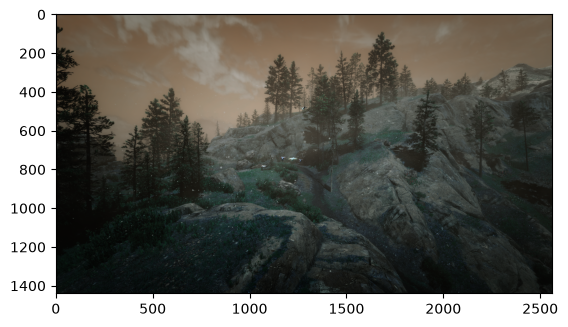

In [ ]:
# plot image using matplotlib
plt.imshow(img)
plt.show()

### Simulate Camera

Image shape: (1440, 2560, 3)
Image dtype: float32
Pixel value range: 54.168701171875 to 5689.0869140625
Mean pixel value: 1215.798828125
Standard deviation of pixel values: 787.6151123046875
Image shape: (1440, 2560, 3)
Image dtype: float64
Pixel value range: 30.799999999999997 to 4296.599999999999
Mean pixel value: 902.3821691713686
Standard deviation of pixel values: 585.1262277056883
Image shape: (1440, 2560, 3)
Image dtype: uint8
Pixel value range: 0 to 116
Mean pixel value: 23.949034288194444
Standard deviation of pixel values: 15.856030548671328


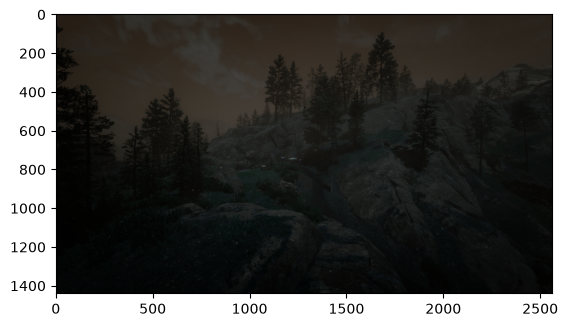

In [2]:

if img is None:
    print(f"Failed to load image from {img_path}")

else:
    # create camera simulation object
    camera_sim = sim.CameraSimulation(iso = sim.iso_values[0], log=True)
    # simulate camera response
    simulated_img = camera_sim.simulate_image(img*5000, depth)
    # plot simulated image
    plt.imshow(simulated_img)
    plt.show()

250 0.25 5.0
250 0.25 9.0
250 0.25 16.0
250 0.016666666666666666 5.0
250 0.016666666666666666 9.0
250 0.016666666666666666 16.0
250 0.001 5.0
250 0.001 9.0
250 0.001 16.0
2000 0.25 5.0
2000 0.25 9.0
2000 0.25 16.0
2000 0.016666666666666666 5.0
2000 0.016666666666666666 9.0
2000 0.016666666666666666 16.0
2000 0.001 5.0
2000 0.001 9.0
2000 0.001 16.0
16000 0.25 5.0
16000 0.25 9.0
16000 0.25 16.0
16000 0.016666666666666666 5.0
16000 0.016666666666666666 9.0
16000 0.016666666666666666 16.0
16000 0.001 5.0
16000 0.001 9.0
16000 0.001 16.0


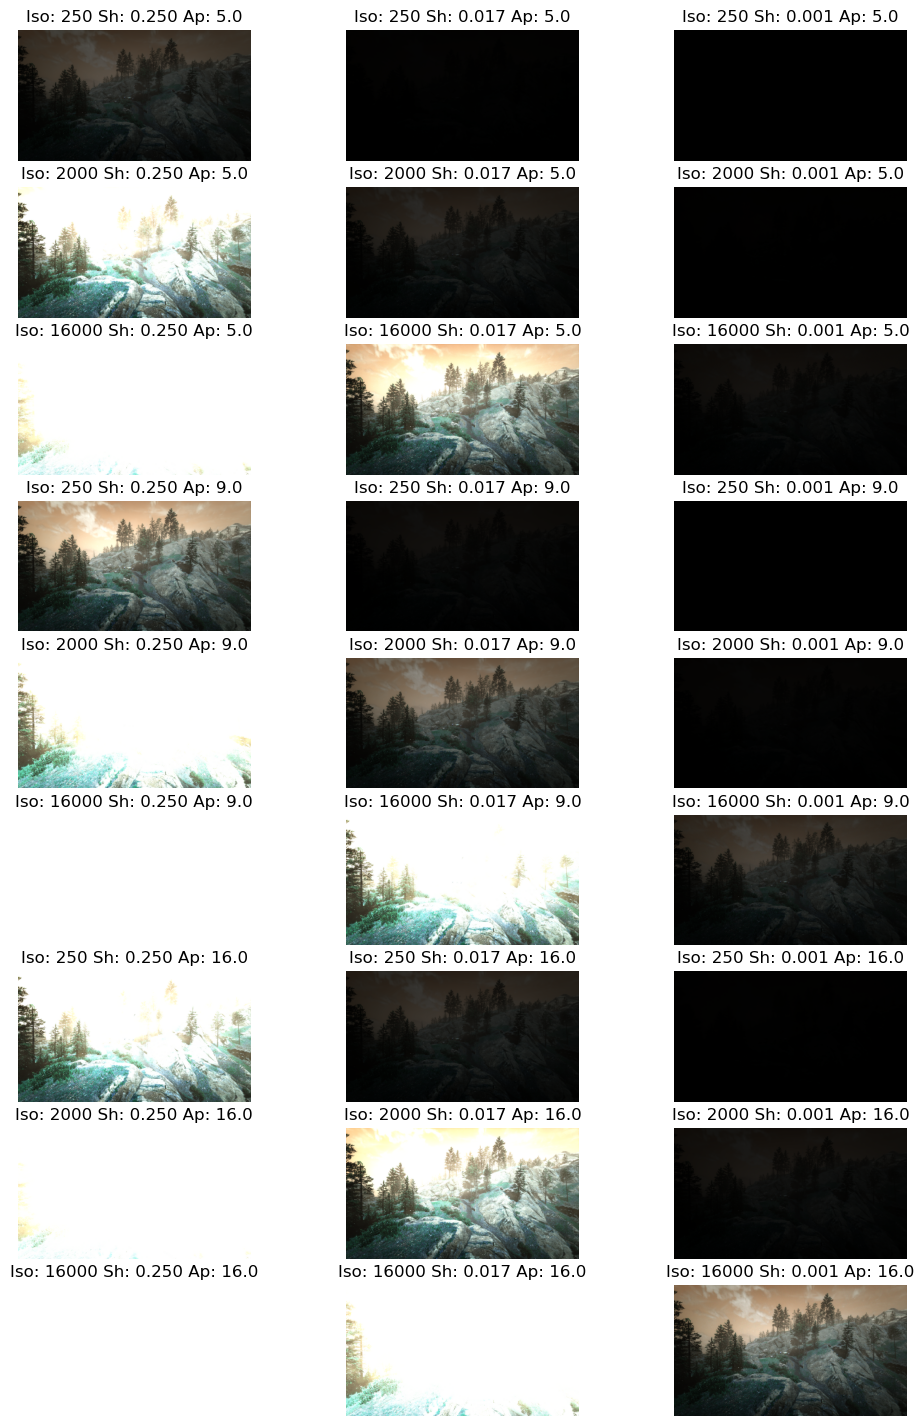

In [ ]:
fig, ax = plt.subplots(9,3, figsize=(12,18))

cam = sim.CameraSimulation(log=False)
images = []

for i in range(3):
    for j in range(3):
        for k in range(3):
            iso = sim.iso_values[i]
            shutter_speed = sim.shutter_speed_values[j]
            aperture = sim.aperture_values[k]
            print(iso, shutter_speed, aperture)
            cam.set_parameters(iso=iso, shutter_speed=shutter_speed, aperture=aperture)
            simulation = cam.simulate_image(img*5000, depth)
            ax[k*3+i][j].imshow(simulation)
            ax[k*3+i][j].axis('off')
            ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")



plt.show()


In [ ]:
fig, ax = plt.subplots(9,3, figsize=(12,18))

cam = camera_module.CameraModule()
images = []

for i in range(3):
    for j in range(3):
        for k in range(3):
            iso = sim.iso_values[i]
            shutter_speed = sim.shutter_speed_values[j]
            aperture = sim.aperture_values[k]
            print(iso, shutter_speed, aperture)
            cam.set_parameters(iso=iso, shutter_speed=shutter_speed, aperture=aperture)
            simulation = cam.forward(img*5000)
            ax[k*3+i][j].imshow(simulation)
            ax[k*3+i][j].axis('off')
            ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")



plt.show()

250 0.25 5.0
250 0.25 9.0
250 0.25 16.0
250 0.016666666666666666 5.0
250 0.016666666666666666 9.0
250 0.016666666666666666 16.0
250 0.001 5.0
250 0.001 9.0
250 0.001 16.0
2000 0.25 5.0
2000 0.25 9.0
2000 0.25 16.0
2000 0.016666666666666666 5.0
2000 0.016666666666666666 9.0
2000 0.016666666666666666 16.0
2000 0.001 5.0
2000 0.001 9.0
2000 0.001 16.0
16000 0.25 5.0
16000 0.25 9.0
16000 0.25 16.0
16000 0.016666666666666666 5.0
16000 0.016666666666666666 9.0
16000 0.016666666666666666 16.0
16000 0.001 5.0
16000 0.001 9.0
16000 0.001 16.0


: 

### Read RAW ARW files

In [5]:


with rawpy.imread("H:/kamera_bilder_meta/ottoturm_hell/ISO250_F9_sh1-60.ARW") as raw:
    rgb = raw.postprocess(
        use_camera_wb=False,
        use_auto_wb=False,
        no_auto_bright=True,
        output_bps=16,
        gamma=(1, 1),      # linear
        bright=1.0,
        user_flip=0,
        demosaic_algorithm=rawpy.DemosaicAlgorithm.AHD
    )

In [4]:
print(rgb.shape)
print(np.max(rgb))

(4024, 6024, 3)
65535


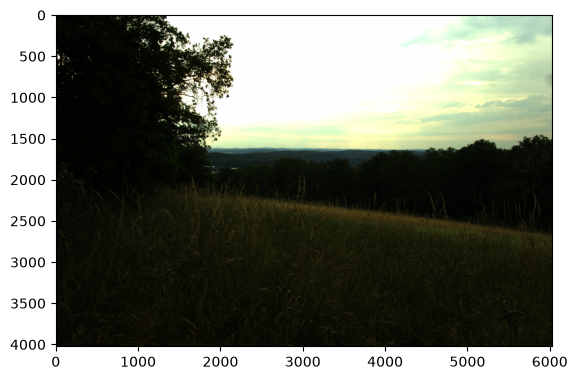

In [6]:
import matplotlib.pyplot as plt

import numpy as np


rgb_norm = (rgb/65535)#np.max(rgb))

plt.imshow(rgb_norm)
plt.show()

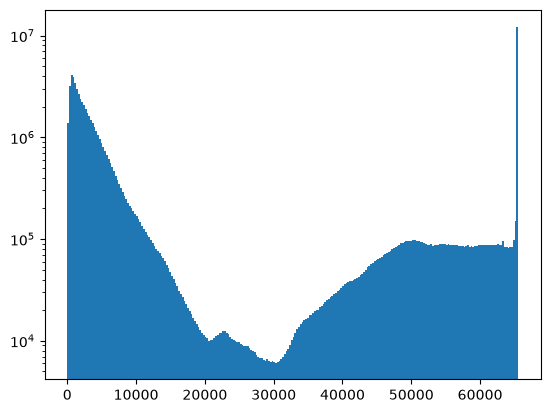

In [10]:
plt.hist(rgb.flatten(), 256)
plt.yscale("log")
plt.show()

65536

### Plot ARW Files

In [8]:
image_name = "wellersberg_wald_abend"
image_path = Path("H:/kamera_bilder_meta") / image_name
imgs = comp.load_image_files_to_matrix(image_path)

Load Files to Matrix: 100%|██████████| 27/27 [00:36<00:00,  1.35s/it]


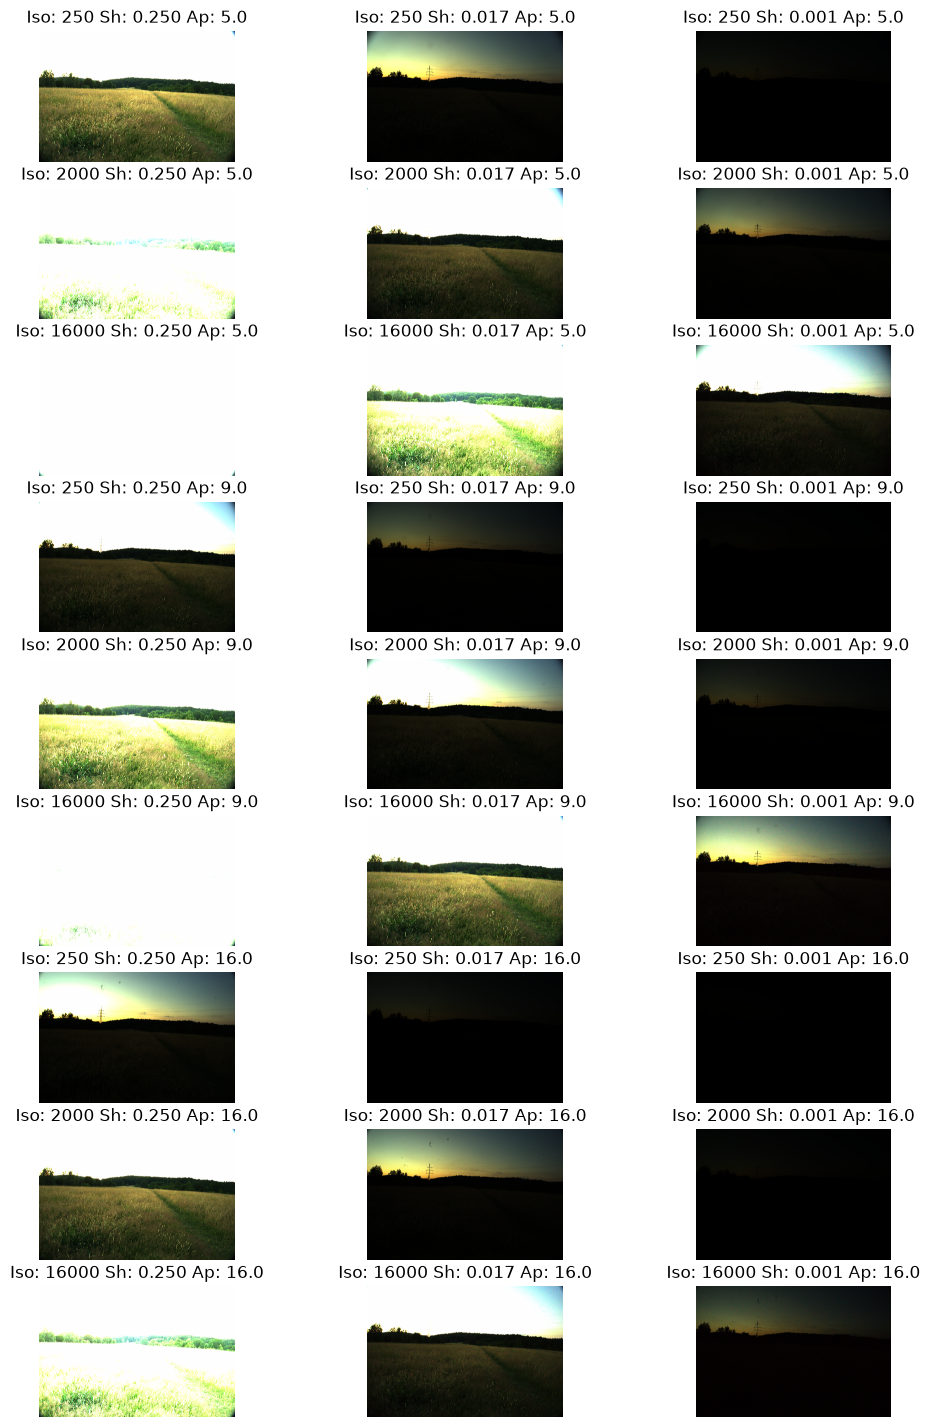

In [9]:
fig, ax = plt.subplots(9,3, figsize=(12,18))

plt.title(image_name)
for i in range(3):
    for j in range(3):
        for k in range(3):
            iso = sim.iso_values[i]
            shutter_speed = sim.shutter_speed_values[j]
            aperture = sim.aperture_values[k]
            image = imgs[i][k][j]
            ax[k*3+i][j].imshow(image)
            ax[k*3+i][j].axis('off')
            ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")


plt.savefig(image_name + "plot.png")
plt.show()

### Compare Sim and Cam

##### Save arw files normalized histograms in npy matrix

In [4]:
for name in ["wellersberg_stadt_nacht", "wellersberg_wald_abend", "wellersberg_wald_nacht"]:
    print(name)
    imgs = comp.load_image_files_to_matrix(Path("H:/kamera_bilder_meta/" + name))
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32))
    np.save('example_images/' + name, hists)
print("done")

wellersberg_stadt_nacht


100%|██████████| 27/27 [00:01<00:00, 16.49it/s]


wellersberg_wald_abend


100%|██████████| 27/27 [00:01<00:00, 18.00it/s]


wellersberg_wald_nacht


100%|██████████| 27/27 [00:01<00:00, 16.41it/s]


done


##### Simulate images and save histframs in npy matrix

In [7]:
input_factor = 5000
exr_directory = Path("H:/example_images/")
npy_dir = Path("./example_images/numpy_files/sim_images") / str(input_factor)
files = [f.stem for f in exr_directory.iterdir() if f.is_file()]
created_files = [f.stem for f in npy_dir.iterdir() if f.is_file()]
for name in tqdm(files, desc="Files"):
    if name in created_files:
        print(f"Skipping {name}, as it already exists")
        continue
    print(f"Create {name} Matrix")
    imgs = comp.simulate_images(exr_directory / (name + ".exr"))
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32), val_range=[0,256])
    np.save(npy_dir / name.split(".")[0], hists)
print("done")

Files:   0%|          | 0/55 [00:00<?, ?it/s]

Create h_1000131_0 Matrix


Files:   2%|▏         | 1/55 [00:32<29:23, 32.66s/it]

Create h_1000131_12 Matrix


Files:   4%|▎         | 2/55 [01:04<28:32, 32.31s/it]

...

Create h_1036201_20 Matrix


Files:  98%|█████████▊| 54/55 [15:42<00:19, 19.84s/it]

Create h_1036201_7 Matrix


Files: 100%|██████████| 55/55 [16:15<00:00, 17.74s/it]

done


"H:\example_images\h_1032500_20.exr" vs wellersberg_wald_abend